# Introducción

Este análisis explora cómo factores como el sueño, el ejercicio, el estrés y otros hábitos afectan la salud mental y el rendimiento académico (GPA) de estudiantes universitarios.

Dataset simulado con características realistas: valores nulos, datos inconsistentes, outliers y errores típicos de entrada.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

df = pd.read_csv("/kaggle/input/salud-mental-en-estudiantes/mental_health_students.csv")

# Vista general del dataset

In [2]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            205 non-null    int64  
 1   age                   205 non-null    int64  
 2   gender                188 non-null    object 
 3   hours_of_sleep        195 non-null    float64
 4   exercise_freq         200 non-null    float64
 5   caffeine_intake       205 non-null    float64
 6   mental_health_rating  205 non-null    int64  
 7   stress_level          196 non-null    object 
 8   seeks_help            163 non-null    object 
 9   diagnosed_disorder    205 non-null    object 
 10  semester_gpa          195 non-null    float64
dtypes: float64(4), int64(3), object(4)
memory usage: 17.7+ KB


,student_id,age,hours_of_sleep,exercise_freq,caffeine_intake,mental_health_rating,semester_gpa
count,205.000000,205.000000,195.000000,200.000000,205.000000,205.000000,195.000000
mean,5324.341463,23.039024,5.970256,2.500000,146.497561,5.126829,2.994588
std,2670.343451,3.633779,2.366876,1.520381,63.155009,3.013615,0.606061
min,1080.000000,17.000000,-2.500000,0.000000,-62.000000,1.000000,0.100000
25%,2745.000000,20.000000,4.500000,1.000000,113.000000,3.000000,2.654606
50%,5394.000000,23.000000,5.800000,3.000000,147.000000,5.000000,2.976031
75%,7643.000000,26.000000,7.800000,4.000000,183.000000,8.000000,3.304114
max,9974.000000,29.000000,11.900000,5.000000,335.000000,10.000000,6.500000


# Limpieza de datos

In [3]:
df['gender'] = df['gender'].replace({'M': 'Male', 'F': 'Female', 'f': 'Female', 'male': 'Male', 'female': 'Female'})
df['gender'] = df['gender'].fillna('Unknown')
df['seeks_help'] = df['seeks_help'].replace({'yes' : 'Yes', 'no' : 'No'})
df['seeks_help'] = df['seeks_help'].fillna('no answer')
df = df.drop_duplicates()

df['hours_of_sleep'] = df['hours_of_sleep'].fillna(df['hours_of_sleep'].median())
df['exercise_freq'] = df['exercise_freq'].fillna(df['exercise_freq'].mode()[0])
df['semester_gpa'] = df['semester_gpa'].fillna(df['semester_gpa'].median())
df['stress_level'] = df['stress_level'].fillna('unknown')

# Análisis Exploratorio de Datos (EDA)

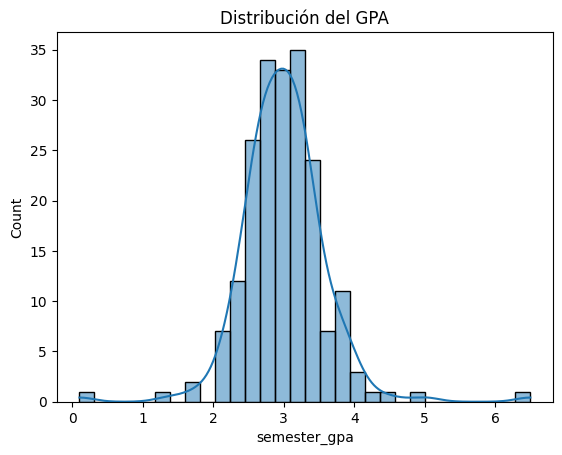

In [4]:
sns.histplot(df['semester_gpa'], kde=True)
plt.title("Distribución del GPA")
plt.show()

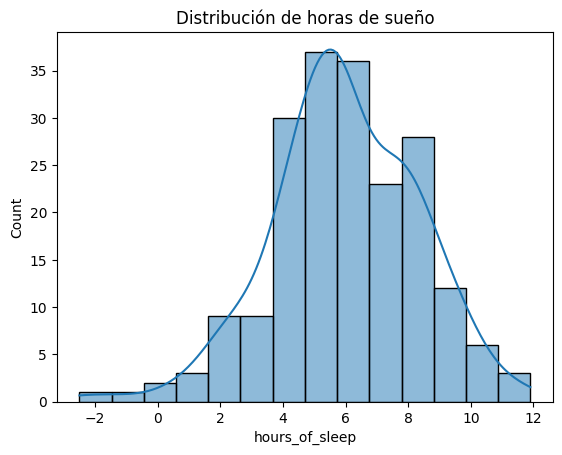

In [5]:
sns.histplot(df['hours_of_sleep'], kde=True)
plt.title("Distribución de horas de sueño")
plt.show()

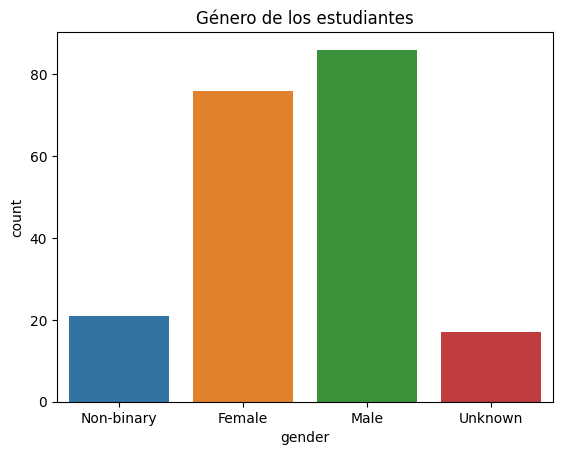

In [6]:
sns.countplot(data=df, x='gender')
plt.title("Género de los estudiantes")
plt.show()

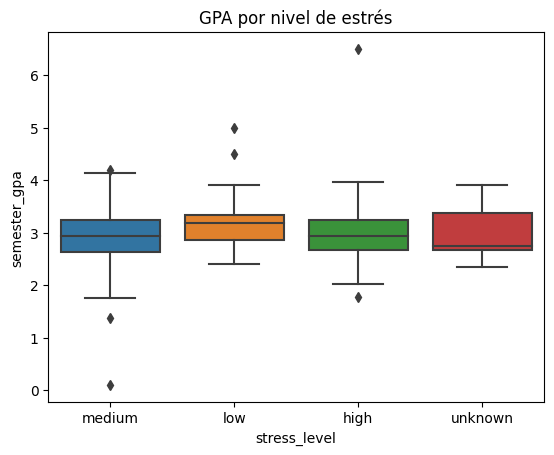

In [7]:
sns.boxplot(data=df, x='stress_level', y='semester_gpa')
plt.title("GPA por nivel de estrés")
plt.show()

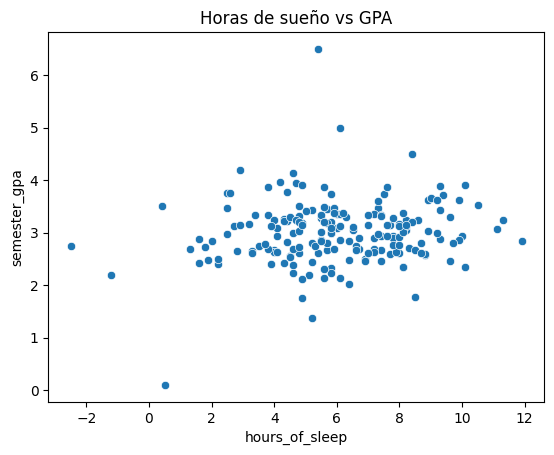

In [8]:
sns.scatterplot(data=df, x='hours_of_sleep', y='semester_gpa')
plt.title("Horas de sueño vs GPA")
plt.show()

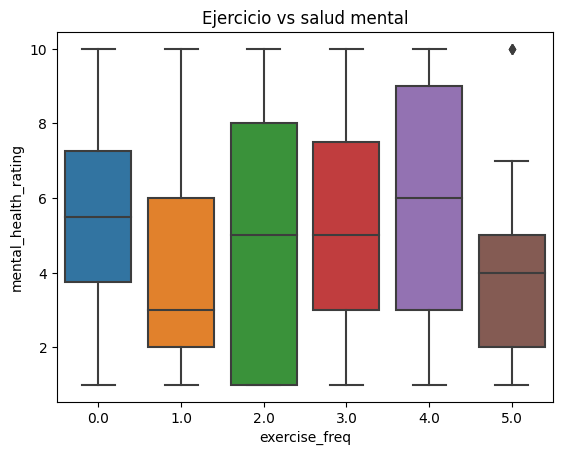

In [9]:
sns.boxplot(data=df, x='exercise_freq', y='mental_health_rating')
plt.title("Ejercicio vs salud mental")
plt.show()

# Conclusiones

- Existen outliers en horas de sueño y GPA que podrían afectar el análisis si no se manejan.
- Se observa que los niveles de estrés tienen impacto en el GPA.
- El ejercicio frecuente parece estar relacionado con una mejor percepción de la salud mental.


# Visualización avanzada y estrategias de imputación

En este bloque analizamos variables relacionadas con salud mental y rendimiento académico en estudiantes universitarios, aplicando estrategias avanzadas de visualización y técnicas adecuadas de imputación.

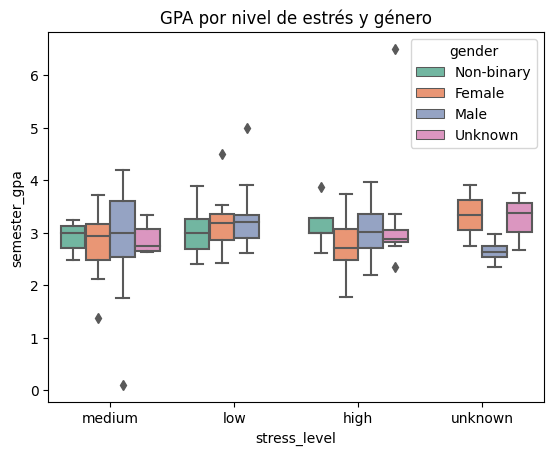

In [10]:
# Visualización con hue y palette
sns.boxplot(data=df, x='stress_level', y='semester_gpa', hue='gender', palette='Set2')
plt.title("GPA por nivel de estrés y género")
plt.show()

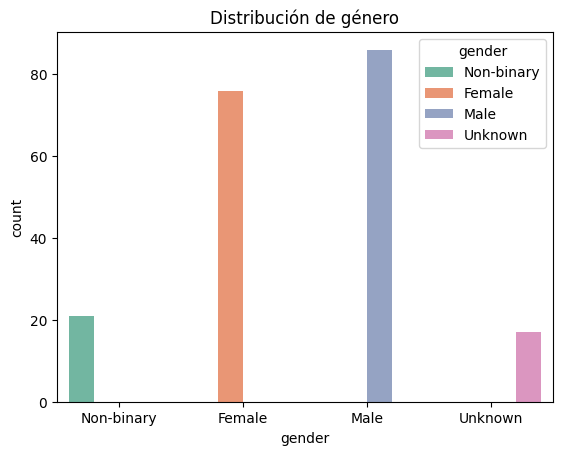

In [11]:
sns.countplot(data=df, x='gender', hue='gender', palette='Set2')
plt.title("Distribución de género")
plt.show()

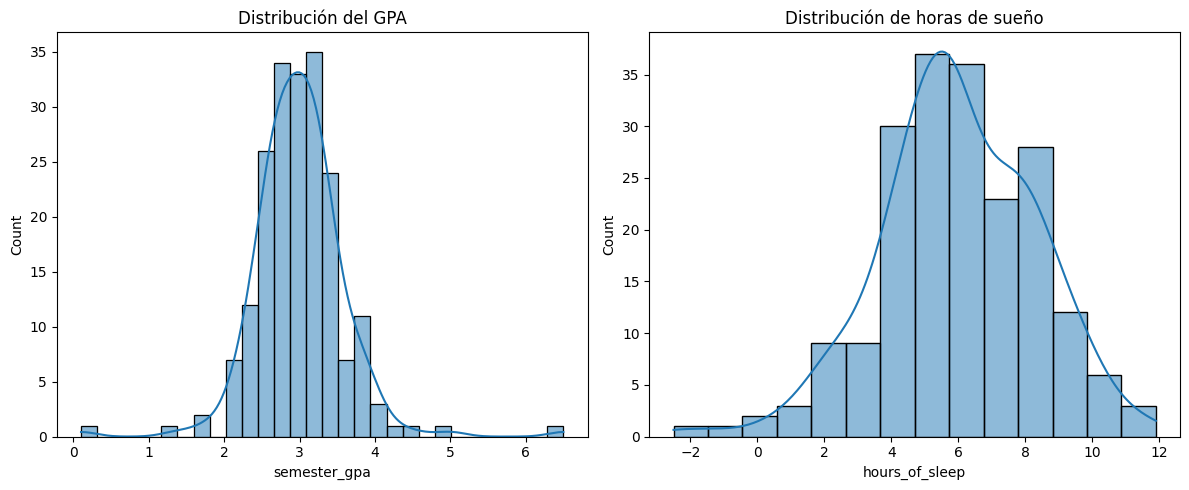

In [12]:
# Subplots comparativos
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=df, x='semester_gpa', kde=True, ax=axs[0])
axs[0].set_title("Distribución del GPA")

sns.histplot(data=df, x='hours_of_sleep', kde=True, ax=axs[1])
axs[1].set_title("Distribución de horas de sueño")

plt.tight_layout()
plt.show()

## Estrategias de Imputación

- `hours_of_sleep`: Imputar con **mediana** (hay outliers).
- `exercise_freq`: Imputar con **moda** (discreta con valores comunes).
- `stress_level`: Imputar con **moda** (ordinal).
- `semester_gpa`: Imputar con **mediana** (hay extremos).
- `gender`: Usar categoría especial `'Unknown'` por falta de moda clara.

## Conclusiones

- Usar `hue` y `palette` permite enriquecer visualmente los análisis comparativos.
- Los `subplots` ayudan a ver múltiples variables en conjunto.
- Elegir bien entre media, mediana y moda evita sesgos al imputar.

# Análisis por Grupo y Visualización Comparativa

En este bloque analizamos cómo cambia el rendimiento académico (GPA) de los estudiantes según factores como género, nivel de estrés y búsqueda de ayuda psicológica. Utilizamos `groupby()` en combinación con `barplot` para visualizar las diferencias entre subgrupos clave.



## GPA promedio por género

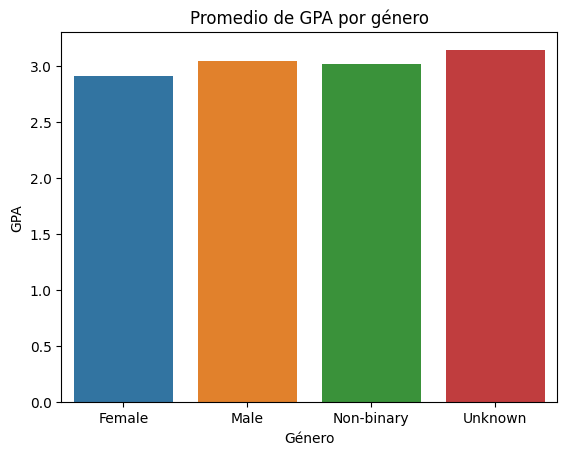

In [13]:
genero_gpa = df.groupby('gender')['semester_gpa'].mean().reset_index()
sns.barplot(data=genero_gpa, x='gender', y='semester_gpa')
plt.title("Promedio de GPA por género")
plt.xlabel("Género")
plt.ylabel("GPA")
plt.show()

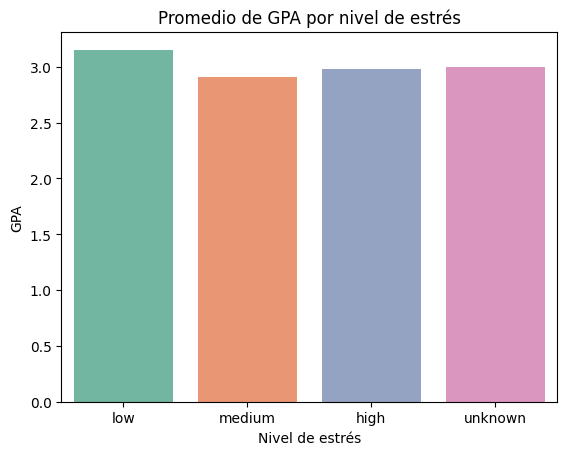

In [14]:
stress_gpa = df.groupby('stress_level')['semester_gpa'].mean().reset_index()
order = ['low', 'medium', 'high', 'unknown']
sns.barplot(data=stress_gpa, x='stress_level', y='semester_gpa', palette='Set2', order=order)
plt.title("Promedio de GPA por nivel de estrés")
plt.xlabel("Nivel de estrés")
plt.ylabel("GPA")
plt.show()

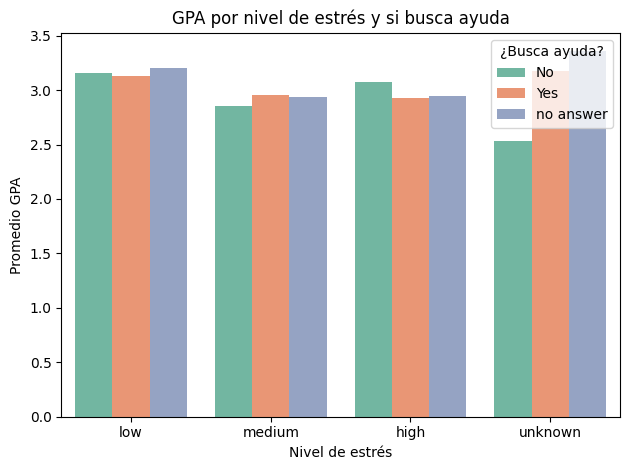

In [15]:
gpa_cross = df.groupby(['stress_level', 'seeks_help'])['semester_gpa'].mean().reset_index()
order = ['low', 'medium', 'high', 'unknown']
sns.barplot(data=gpa_cross, x='stress_level', y='semester_gpa', hue='seeks_help', palette='Set2', order=order)
plt.title("GPA por nivel de estrés y si busca ayuda")
plt.xlabel("Nivel de estrés")
plt.ylabel("Promedio GPA")
plt.legend(title="¿Busca ayuda?")
plt.tight_layout()
plt.show()

# Visualización de Combinaciones Cruzadas con Heatmaps

En este bloque exploramos dos formas de analizar combinaciones entre variables categóricas usando `crosstab()` y `pivot_table()` para generar heatmaps.

---

## Heatmap 1 – Frecuencia de combinaciones (`crosstab`)

Visualizamos cuántos estudiantes hay por combinación de nivel de estrés y si buscan ayuda.

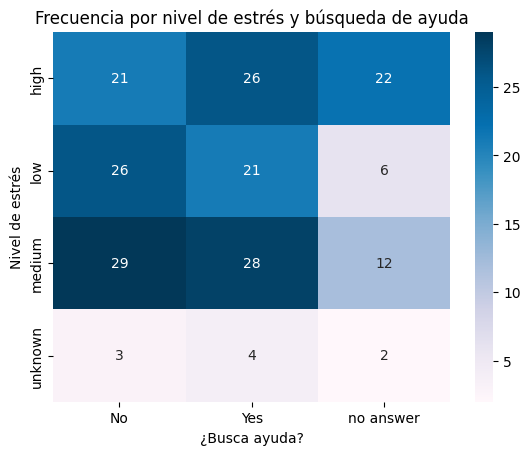

In [16]:
# Tabla cruzada con conteo de frecuencia
tabla_frecuencia = pd.crosstab(df['stress_level'], df['seeks_help'])

# Heatmap de frecuencia
sns.heatmap(tabla_frecuencia, annot=True, cmap="PuBu", fmt='d')
plt.title("Frecuencia por nivel de estrés y búsqueda de ayuda")
plt.xlabel("¿Busca ayuda?")
plt.ylabel("Nivel de estrés")
plt.show()

## Heatmap 2 – Promedio de GPA por combinación (`pivot_table`)

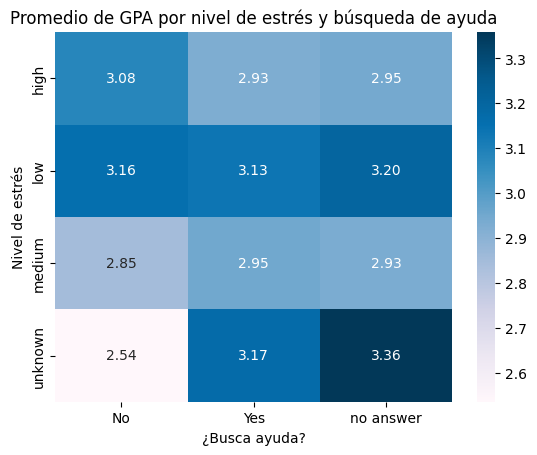

In [17]:
# Tabla dinámica con promedios de GPA
tabla_promedios = pd.pivot_table(df, 
                                  index='stress_level', 
                                  columns='seeks_help', 
                                  values='semester_gpa', 
                                  aggfunc='mean')

# Heatmap de promedio de GPA
sns.heatmap(tabla_promedios, annot=True, cmap="PuBu", fmt=".2f")
plt.title("Promedio de GPA por nivel de estrés y búsqueda de ayuda")
plt.xlabel("¿Busca ayuda?")
plt.ylabel("Nivel de estrés")
plt.show()

# Conclusiones e Insights del Análisis por Grupo

## 1. ¿Quiénes tienen mejor GPA?

- Los estudiantes con **bajo nivel de estrés** presentan, en promedio, **mejor GPA**.
- Sin embargo, dentro del grupo con **alto estrés**, aquellos que **no buscan ayuda** muestran un GPA ligeramente superior que quienes sí lo hacen.
- Esto podría indicar que algunos estudiantes de alto rendimiento prefieren enfrentar la presión académica sin acudir a servicios de apoyo.

## 2. ¿Diferencias entre géneros?

- Se observó que el **GPA promedio en estudiantes masculinos y no binarios** es **ligeramente superior** al de las estudiantes femeninas.
- Es importante analizar este resultado en contextos más amplios antes de llegar a conclusiones definitivas.

## 3. Relación entre estrés y búsqueda de ayuda

- Sorprendentemente, **los estudiantes con menor nivel de estrés son quienes más buscan ayuda**.
- En contraste, quienes **reportan alto estrés tienden a no buscar ayuda**, lo que podría deberse a **falta de tiempo, estigma** o **desconocimiento** de los recursos disponibles.
- Este patrón sugiere un posible **ciclo de rendimiento-exigencia** donde quienes tienen alto GPA también soportan más presión sin buscar apoyo.

## 4. Insight clave para tomar acción institucional

El cruce entre **nivel de estrés, búsqueda de ayuda y GPA** puede guiar a las instituciones a implementar estrategias de apoyo más accesibles, menos invasivas en tiempo, y que **no comprometan el rendimiento académico**. 
Además, podría enfocarse en **romper estigmas** y **promover una cultura preventiva del bienestar emocional**, especialmente en estudiantes de alto rendimiento.

# Cierre personal

Este proyecto me permitió aplicar de forma estructurada los conocimientos adquiridos sobre limpieza de datos, visualización exploratoria, análisis por grupo y estrategias de imputación. Fue desarrollado como parte de un programa intensivo enfocado en construir un portafolio profesional sólido en análisis de datos.

Además de la práctica técnica, este análisis también integró habilidades de comunicación, interpretación de resultados y generación de insights accionables, los cuales son clave para la toma de decisiones basada en datos.